# Planning Plots

In [4]:
import sys
sys.path.append('/Users/gianmarcotedeschi/Projects/learnRL/')

In [1]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt
import json
# from simulation.trajectory_sampler import *
# from envs import *
# from policies import *
# from data_processors import *
from scipy.stats import sem, t
import os
import tikzplotlib as tikz

# font = {'size'   : 14}
# plt.rc('font', **font)  # pass in the font dict as kwargs

# GAPS
# font = {'size'   : 20}
# plt.rc('font', **font)  # pass in the font dict as kwargs



In [7]:
# Funzione per caricare i dati da un percorso
def load_trials(base_path, n_exp):
    trial_performances = []
    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_performances.append(data["performance"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_performances)  # Converte in array per calcoli successivi

# RESULTS

In [17]:
# # Path principali per i risultati

# paths = [
#     "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_17-01_14_CLOL_Planning_500_swimmer_500_10_0995_constant_0001_10_noclip__deep_gaussian_2150_std_1",
#     "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_17-01_14_CLOL_Planning_500_swimmer_500_1_0995_constant_0001_10_noclip__deep_gaussian_1700_std_1",
#     "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_17-01_14_CLOL_Planning_500_swimmer_500_2_0995_constant_0001_10_noclip__deep_gaussian_1750_std_1",
#     "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_17-01_14_CLOL_Planning_500_swimmer_500_3_0995_constant_0001_10_noclip__deep_gaussian_1800_std_1",
#     "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_17-01_14_CLOL_Planning_500_swimmer_500_5_0995_constant_0001_10_noclip__deep_gaussian_1900_std_1",
#     "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_18-15_31_CLOL_Planning_500_swimmer_500_1_0995_constant_0001_10_noclip__persistence_deep_gaussian_1700_std_1",
#     "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_18-15_31_CLOL_Planning_500_swimmer_500_2_0995_constant_0001_10_noclip__persistence_deep_gaussian_1700_std_1",
#     "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_18-15_31_CLOL_Planning_500_swimmer_500_3_0995_constant_0001_10_noclip__persistence_deep_gaussian_1700_std_1",
#     "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_18-15_31_CLOL_Planning_500_swimmer_500_5_0995_constant_0001_10_noclip__persistence_deep_gaussian_1700_std_1",
#     "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_18-15_31_CLOL_Planning_500_swimmer_500_10_0995_constant_0001_10_noclip__persistence_deep_gaussian_1700_std_1",

# ]

# Swimmer planning with persistence results
paths = [
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-16_27_CLOL_Planning_500_swimmer_700_1_0995_constant_0001_100_noclip__deep_gaussian_1700_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-16_27_CLOL_Planning_500_swimmer_700_2_0995_constant_0001_100_noclip__deep_gaussian_1750_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-16_27_CLOL_Planning_500_swimmer_700_3_0995_constant_0001_100_noclip__deep_gaussian_1800_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-16_27_CLOL_Planning_500_swimmer_700_5_0995_constant_0001_100_noclip__deep_gaussian_1900_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-16_27_CLOL_Planning_500_swimmer_700_10_0995_constant_0001_100_noclip__deep_gaussian_2150_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-13_34_CLOL_Planning_500_swimmer_700_1_0995_constant_0001_100_noclip__persistence_deep_gaussian_1700_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-13_34_CLOL_Planning_500_swimmer_700_2_0995_constant_0001_100_noclip__persistence_deep_gaussian_1700_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-13_34_CLOL_Planning_500_swimmer_700_3_0995_constant_0001_100_noclip__persistence_deep_gaussian_1700_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-13_34_CLOL_Planning_500_swimmer_700_5_0995_constant_0001_100_noclip__persistence_deep_gaussian_1700_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-13_34_CLOL_Planning_500_swimmer_700_10_0995_constant_0001_100_noclip__persistence_deep_gaussian_1700_std_1_noise_00"

    # Normal
    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_26-14_15_CLOL_Planning_500_swimmer_700_1_0995_constant_0001_100_noclip__deep_gaussian_1700_std_1",
    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_26-14_15_CLOL_Planning_500_swimmer_700_2_0995_constant_0001_100_noclip__deep_gaussian_1750_std_1",
    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_26-14_15_CLOL_Planning_500_swimmer_700_3_0995_constant_0001_100_noclip__deep_gaussian_1800_std_1",
    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_26-14_15_CLOL_Planning_500_swimmer_700_5_0995_constant_0001_100_noclip__deep_gaussian_1900_std_1",
    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_26-14_15_CLOL_Planning_500_swimmer_700_10_0995_constant_0001_100_noclip__deep_gaussian_2150_std_1",

    # Persistence
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-20_58_CLOL_Planning_500_swimmer_700_1_0995_constant_0001_100_noclip__persistence_deep_gaussian_1700_std_1_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-20_58_CLOL_Planning_500_swimmer_700_2_0995_constant_0001_100_noclip__persistence_deep_gaussian_1700_std_1_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-20_58_CLOL_Planning_500_swimmer_700_3_0995_constant_0001_100_noclip__persistence_deep_gaussian_1700_std_1_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-20_58_CLOL_Planning_500_swimmer_700_5_0995_constant_0001_100_noclip__persistence_deep_gaussian_1700_std_1_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-20_58_CLOL_Planning_500_swimmer_700_10_0995_constant_0001_100_noclip__persistence_deep_gaussian_1700_std_1_noise_00",

    # Reinforce
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-18_30_CLOL_Planning_500_swimmer_700_1_0995_constant_0001_100_noclip__deep_gaussian_1700_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-18_30_CLOL_Planning_500_swimmer_700_2_0995_constant_0001_100_noclip__deep_gaussian_1750_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-18_30_CLOL_Planning_500_swimmer_700_3_0995_constant_0001_100_noclip__deep_gaussian_1800_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-18_30_CLOL_Planning_500_swimmer_700_5_0995_constant_0001_100_noclip__deep_gaussian_1900_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-18_30_CLOL_Planning_500_swimmer_700_10_0995_constant_0001_100_noclip__deep_gaussian_2150_std_1_noise_00",
]

# # Half cheetah planning with persistence results
# paths = [
#     # Normal
#     "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-00_05_CLOL_Planning_500_half_cheetah_200_1_0999_adam_0001_10_noclip__deep_gaussian_2250_std_01_noise_00",
#     "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-00_05_CLOL_Planning_500_half_cheetah_200_2_0999_adam_0001_10_noclip__deep_gaussian_2400_std_01_noise_00",
#     "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-00_05_CLOL_Planning_500_half_cheetah_200_3_0999_adam_0001_10_noclip__deep_gaussian_2550_std_01_noise_00",
#     "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-00_05_CLOL_Planning_500_half_cheetah_200_5_0999_adam_0001_10_noclip__deep_gaussian_2850_std_01_noise_00",
#     "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-00_05_CLOL_Planning_500_half_cheetah_200_10_0999_adam_0001_10_noclip__deep_gaussian_3600_std_01_noise_00",

#     # Persistence
#     # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-22_26_CLOL_Planning_500_half_cheetah_200_1_0999_adam_0001_10_noclip__persistence_deep_gaussian_2250_std_01_noise_00",
#     "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-22_26_CLOL_Planning_500_half_cheetah_200_2_0999_adam_0001_10_noclip__persistence_deep_gaussian_2250_std_01_noise_00",
#     "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-22_26_CLOL_Planning_500_half_cheetah_200_3_0999_adam_0001_10_noclip__persistence_deep_gaussian_2250_std_01_noise_00",
#     "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-22_26_CLOL_Planning_500_half_cheetah_200_5_0999_adam_0001_10_noclip__persistence_deep_gaussian_2250_std_01_noise_00",
#     "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_03-22_26_CLOL_Planning_500_half_cheetah_200_10_0999_adam_0001_10_noclip__persistence_deep_gaussian_2250_std_01_noise_00",

# #     # REINFORCE
# #     "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-15_28_CLOL_Planning_500_half_cheetah_200_1_0999_adam_0001_10_noclip__deep_gaussian_2250_std_01_noise_00",
# #     "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-15_28_CLOL_Planning_500_half_cheetah_200_2_0999_adam_0001_10_noclip__deep_gaussian_2400_std_01_noise_00",
# #     "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-15_28_CLOL_Planning_500_half_cheetah_200_3_0999_adam_0001_10_noclip__deep_gaussian_2550_std_01_noise_00",
# #     "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-15_28_CLOL_Planning_500_half_cheetah_200_5_0999_adam_0001_10_noclip__deep_gaussian_2850_std_01_noise_00",
# #     "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-15_28_CLOL_Planning_500_half_cheetah_200_10_0999_adam_0001_10_noclip__deep_gaussian_3600_std_01_noise_00"
# ]

# Dam planning with persistence results
paths = [
    # Normal
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-10_08_CLOL_Planning_100_dam_1825_1_0999_adam_0005_10_noclip__deep_gaussian_1625_std_05_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-10_08_CLOL_Planning_100_dam_1825_2_0999_adam_0005_10_noclip__deep_gaussian_1650_std_05_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-10_08_CLOL_Planning_100_dam_1825_3_0999_adam_0005_10_noclip__deep_gaussian_1675_std_05_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-10_08_CLOL_Planning_100_dam_1825_5_0999_adam_0005_10_noclip__deep_gaussian_1725_std_05_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-10_08_CLOL_Planning_100_dam_1825_10_0999_adam_0005_10_noclip__deep_gaussian_1850_std_05_noise_00",

    # Persistence
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-10_07_CLOL_Planning_100_dam_1825_1_0999_adam_0005_10_noclip__persistence_deep_gaussian_1625_std_05_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-10_07_CLOL_Planning_100_dam_1825_2_0999_adam_0005_10_noclip__persistence_deep_gaussian_1625_std_05_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-10_07_CLOL_Planning_100_dam_1825_3_0999_adam_0005_10_noclip__persistence_deep_gaussian_1625_std_05_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-10_07_CLOL_Planning_100_dam_1825_5_0999_adam_0005_10_noclip__persistence_deep_gaussian_1625_std_05_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-10_07_CLOL_Planning_100_dam_1825_10_0999_adam_0005_10_noclip__persistence_deep_gaussian_1625_std_05_noise_00",
    
    # REINFORCE
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-15_28_CLOL_Planning_100_dam_1825_1_0999_adam_0005_10_noclip__deep_gaussian_1625_std_05_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-15_28_CLOL_Planning_100_dam_1825_2_0999_adam_0005_10_noclip__deep_gaussian_1650_std_05_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-15_28_CLOL_Planning_100_dam_1825_3_0999_adam_0005_10_noclip__deep_gaussian_1675_std_05_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-15_28_CLOL_Planning_100_dam_1825_5_0999_adam_0005_10_noclip__deep_gaussian_1725_std_05_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new/_02_04-15_28_CLOL_Planning_100_dam_1825_10_0999_adam_0005_10_noclip__deep_gaussian_1850_std_05_noise_00",
]

# Labels per i trial
lab = [
    "W = 1",
    "W = 2",
    "W = 3",
    "W = 5",
    "W = 10",
    # "T = 1",
    "T = 2",
    "T = 3",
    "T = 5",
    "T = 10",
    # "W = 1 (REINFORCE)",
    # "W = 2 (REINFORCE)",
    # "W = 3 (REINFORCE)",
    # "W = 5 (REINFORCE)",
    # "W = 10 (REINFORCE)",
]

In [26]:
paths = [
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_12-16_49_CLOL_Planning_100_dam_1825_1_0999_adam_001_10_noclip__deep_gaussian_1625_std_05_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_10-15_46_CLOL_Planning_100_dam_1825_1_0999_adam_0005_10_noclip__deep_gaussian_1625_std_05_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_12-16_49_CLOL_Planning_100_dam_1825_2_0999_adam_001_10_noclip__deep_gaussian_1650_std_05_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_12-16_49_CLOL_Planning_100_dam_1825_3_0999_adam_001_10_noclip__deep_gaussian_1675_std_05_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_12-16_49_CLOL_Planning_100_dam_1825_5_0999_adam_001_10_noclip__deep_gaussian_1725_std_05_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_12-16_49_CLOL_Planning_100_dam_1825_10_0999_adam_001_10_noclip__deep_gaussian_1850_std_05_noise_00",

    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_10-15_46_CLOL_Planning_100_dam_1825_2_0999_adam_0005_10_noclip__deep_gaussian_1650_std_05_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_10-15_46_CLOL_Planning_100_dam_1825_3_0999_adam_0005_10_noclip__deep_gaussian_1675_std_05_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_10-15_46_CLOL_Planning_100_dam_1825_5_0999_adam_0005_10_noclip__deep_gaussian_1725_std_05_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_10-15_46_CLOL_Planning_100_dam_1825_10_0999_adam_0005_10_noclip__deep_gaussian_1850_std_05_noise_00"
]

paths = [
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_10-15_44_CLOL_Planning_500_half_cheetah_200_1_0999_adam_00005_10_noclip__deep_gaussian_2250_std_01_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_10-15_44_CLOL_Planning_500_half_cheetah_200_2_0999_adam_00005_10_noclip__deep_gaussian_2400_std_01_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_10-15_44_CLOL_Planning_500_half_cheetah_200_3_0999_adam_00005_10_noclip__deep_gaussian_2550_std_01_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_10-15_44_CLOL_Planning_500_half_cheetah_200_5_0999_adam_00005_10_noclip__deep_gaussian_2850_std_01_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_10-15_44_CLOL_Planning_500_half_cheetah_200_10_0999_adam_00005_10_noclip__deep_gaussian_3600_std_01_noise_00"
]

paths = [
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_10-15_54_CLOL_Planning_500_swimmer_700_1_0995_constant_0001_100_noclip__deep_gaussian_1700_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_10-15_54_CLOL_Planning_500_swimmer_700_2_0995_constant_0001_100_noclip__deep_gaussian_1750_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_10-15_54_CLOL_Planning_500_swimmer_700_3_0995_constant_0001_100_noclip__deep_gaussian_1800_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_10-15_54_CLOL_Planning_500_swimmer_700_5_0995_constant_0001_100_noclip__deep_gaussian_1900_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_10-15_54_CLOL_Planning_500_swimmer_700_10_0995_constant_0001_100_noclip__deep_gaussian_2150_std_1_noise_00",
    
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_11-10_53_CLOL_Planning_500_swimmer_700_1_0995_constant_0005_100_noclip__deep_gaussian_1700_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_11-10_53_CLOL_Planning_500_swimmer_700_2_0995_constant_0005_100_noclip__deep_gaussian_1750_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_11-10_53_CLOL_Planning_500_swimmer_700_3_0995_constant_0005_100_noclip__deep_gaussian_1800_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_11-10_53_CLOL_Planning_500_swimmer_700_5_0995_constant_0005_100_noclip__deep_gaussian_1900_std_1_noise_00",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_11-10_53_CLOL_Planning_500_swimmer_700_10_0995_constant_0005_100_noclip__deep_gaussian_2150_std_1_noise_00",
    
    # "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_11-18_03_CLOL_Planning_500_swimmer_700_1_0995_constant_001_100_noclip__deep_gaussian_1700_std_1_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_11-18_03_CLOL_Planning_500_swimmer_700_2_0995_constant_001_100_noclip__deep_gaussian_1750_std_1_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_11-18_03_CLOL_Planning_500_swimmer_700_3_0995_constant_001_100_noclip__deep_gaussian_1800_std_1_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_11-18_03_CLOL_Planning_500_swimmer_700_5_0995_constant_001_100_noclip__deep_gaussian_1900_std_1_noise_00",
    "/Users/gianmarcotedeschi/Projects/learnRL/results-new-persistence-REINFORCE/_02_11-18_03_CLOL_Planning_500_swimmer_700_10_0995_constant_001_100_noclip__deep_gaussian_2150_std_1_noise_00"
]

lab = [
    "W = 1",
    "W = 2",
    "W = 3",
    "W = 5",
    "W = 10",
]

In [29]:
paths = [

    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_29-08_53_CLOL_Planning_500_swimmer_700_1_0999_constant_0001_100_noclip__deep_gaussian_1700_std_1",
    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_29-08_53_CLOL_Planning_500_swimmer_700_2_0999_constant_0001_100_noclip__deep_gaussian_1750_std_1", 
    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_29-08_53_CLOL_Planning_500_swimmer_700_3_0999_constant_0001_100_noclip__deep_gaussian_1800_std_1", 
    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_29-08_53_CLOL_Planning_500_swimmer_700_5_0999_constant_0001_100_noclip__deep_gaussian_1900_std_1", 
    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/swimmer_paper/_01_29-08_53_CLOL_Planning_500_swimmer_700_10_0999_constant_0001_100_noclip__deep_gaussian_2150_std_1",

]

lab = [
    "W = 1",
    "W = 2",
    "W = 3",
    "W = 5",
    "W = 10",
]

In [33]:
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=8)
    # print(f"Loaded {performances.size} performances from {path}")
    if performances.size > 0:
        all_performances.append(performances)

In [15]:
print(len(all_performances))

9


<Figure size 640x480 with 0 Axes>

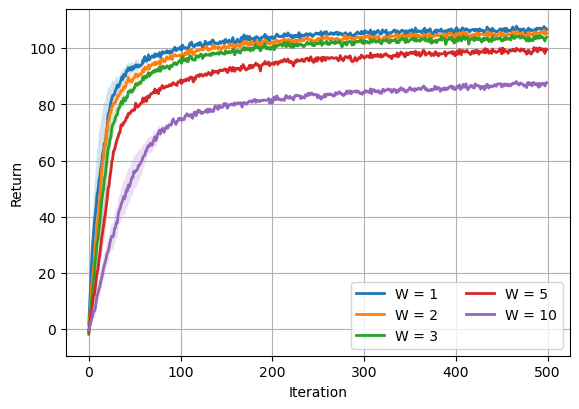

In [34]:
# Plot dei grafici
plt.clf()
plt.figure(figsize=(6.5, 4.5))
# plt.figure(figsize=(10, 6))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, linewidth=2, label=lab[i])

        # Plot dell'intervallo di confidenza
        lower = mean_performance-(std_performance)*1.96/np.sqrt(performances.shape[0])
        higher = mean_performance+(std_performance)*1.96/np.sqrt(performances.shape[0])

        plt.fill_between(
            range(len(mean_performance)),
            lower,
            higher,
            alpha=0.2
        )

        # print(np.mean(mean_performance))
        # print(np.mean(lower))
        # print(np.mean(higher))

# Etichette e titolo
# plt.title("Dam")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend(loc="lower right", ncol=2)
plt.grid()
# plt.ylim(bottom=-80)
# plt.xlim(right=100)
# Salva e mostra il grafico
# plt.savefig("swimmer_persistence.pdf", format='pdf', bbox_inches='tight')
tikz.save("swimmer_700_b100_g_0999.tex")
plt.show()

Successfully generated and saved: /Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/all_paper_plots/swimmer_500_b100_g0995.pdf.DIOPORCO (Plotted 5 curves)
Successfully generated and saved: /Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/all_paper_plots/swimmer_200_b100_g0999.pdf.DIOPORCO (Plotted 5 curves)
Successfully generated and saved: /Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/all_paper_plots/swimmer_200_b10_g0999.pdf.DIOPORCO (Plotted 5 curves)
Successfully generated and saved: /Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/all_paper_plots/swimmer_200_b10_g0995.pdf.DIOPORCO (Plotted 5 curves)
Successfully generated and saved: /Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/all_paper_plots/swimmer_500_b10_g0995.pdf.DIOPORCO (Plotted 5 curves)
Successfully generated and saved: /Users/gianmarcotedeschi

KeyboardInterrupt: 

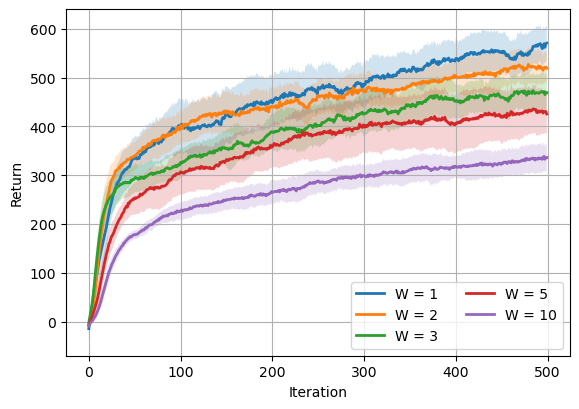

In [10]:
import os
import json
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import tikzplotlib as tikz

# 1. Function to load data
def load_trials(base_path, n_exp=10):
    trial_performances = []
    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_performances.append(data["performance"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_performances)

# 2. Setup paths and mappings
root_dir = '/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/'
paper_results_path = os.path.join(root_dir, 'paper-results')

output_dir = os.path.join(root_dir, 'paper-results', 'all_paper_plots')
os.makedirs(output_dir, exist_ok=True) 

env_abbreviations = {
    "half_cheetah": "hc",
}

pattern = re.compile(r"^(.*?)CLOL_Planning_(\d+)_(.*?)_(\d+)_(\d+)_(\d+)_[a-zA-Z]+_\d+_(\d+)")

grouped_experiments = defaultdict(list)

# 3. Parse directories and group them
for env_paper in os.listdir(paper_results_path):
    env_paper_dir = os.path.join(paper_results_path, env_paper)
    
    if not os.path.isdir(env_paper_dir) or not env_paper.endswith('_paper'):
        continue

    for exp_folder in os.listdir(env_paper_dir):
        exp_path = os.path.join(env_paper_dir, exp_folder)
        if not os.path.isdir(exp_path):
            continue

        # --- NEW: Skip the folder entirely if it's a persistence run ---
        if "persistence" in exp_folder.lower():
            continue

        match = pattern.search(exp_folder)
        if match:
            timestamp_prefix = match.group(1)
            iterations = match.group(2)
            env = match.group(3)
            horizon = match.group(4)
            w_param = int(match.group(5))
            discount = match.group(6)
            batch = match.group(7)

            # Standard group key without persistence flag
            group_key = (timestamp_prefix, iterations, env, horizon, discount, batch)
            grouped_experiments[group_key].append((w_param, exp_path))

# 4. Plot and save results for each group
for (timestamp, iterations, env, horizon, discount, batch), exp_list in grouped_experiments.items():
    
    exp_list.sort(key=lambda x: x[0])
    
    plt.figure(figsize=(6.5, 4.5))
    lines_plotted = 0

    for w_param, path in exp_list:
        performances = load_trials(path, n_exp=10)
        
        if performances.size > 0:
            lines_plotted += 1
            mean_performance = np.mean(performances, axis=0)
            std_performance = np.std(performances, axis=0)
            n_trials = performances.shape[0]

            plt.plot(mean_performance, linewidth=2, label=f"W = {w_param}")

            lower = mean_performance - (std_performance * 1.96 / np.sqrt(n_trials))
            higher = mean_performance + (std_performance * 1.96 / np.sqrt(n_trials))

            plt.fill_between(
                range(len(mean_performance)),
                lower,
                higher,
                alpha=0.2
            )

    if lines_plotted == 0:
        plt.close()
        continue

    plt.xlabel("Iteration")
    plt.ylabel("Return")
    plt.legend(loc="lower right", ncol=2)
    plt.grid(True)
    
    short_env = env_abbreviations.get(env, env)
    
    base_filename = f"{short_env}_{horizon}_b{batch}_g{discount}"
    filename = f"{base_filename}.pdf.DIOPORCO"
    save_path = os.path.join(output_dir, filename)

    # Fail-safe to avoid overwriting duplicate identical configurations
    counter = 1
    while os.path.exists(save_path):
        filename = f"{base_filename}_{counter}.pdf"
        save_path = os.path.join(output_dir, filename)

    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    tikz.save(f'{save_path}.tex')
    
    plt.close()
    
    print(f"Successfully generated and saved: {save_path} (Plotted {lines_plotted} curves)")

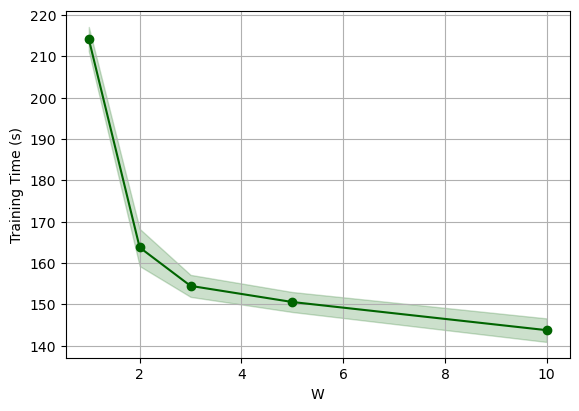

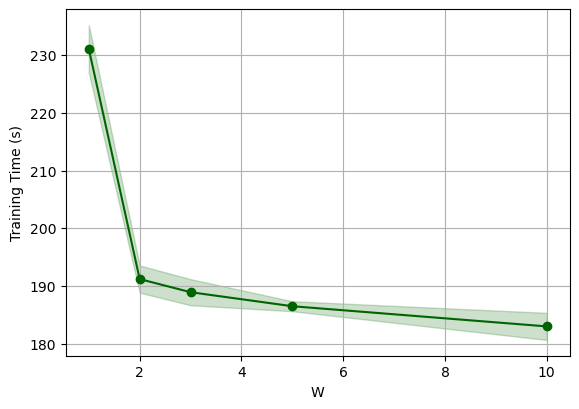

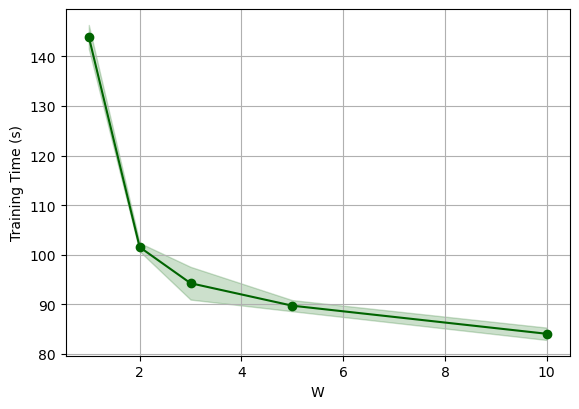

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import tikzplotlib as tikz


def plot_time(time, name):
    # Calcolo della media e dell'intervallo di confidenza al 95%
    means = np.mean(time, axis=1)
    std_err = st.sem(time, axis=1)  # Errore standard della media
    conf_interval = st.t.ppf(0.975, df=time.shape[1]-1) * std_err  # IC 95%

    # Creazione del plot
    plt.figure(figsize=(6.5, 4.5))
    plt.plot(W, means, marker='o', linestyle='-', color='darkgreen', label="Tempo medio")
    plt.fill_between(W, means - conf_interval, means + conf_interval, color='darkgreen', alpha=0.2, label="IC 95%")

    # Etichette e titolo
    plt.xlabel("W")
    plt.ylabel("Training Time (s)")
    # plt.legend()
    plt.grid(True)
    # plt.savefig(f"{name}.pdf", format='pdf', bbox_inches='tight')
    root_dir = '/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/'
    output_dir = os.path.join(root_dir, 'paper-results', 'all_paper_plots')
    tikz.save(f'{output_dir}/{name}.tex')
    
    # Mostra il grafico
    plt.show()


# Dati
W = np.array([1, 2, 3, 5, 10])

t_swimmer = np.array([
    [216.67487502098083, 211.55509781837463, 215.8310980796814, 211.7168321609497, 214.8923680782318],
    [169.08571195602417, 158.86522889137268, 163.52318000793457, 163.28808498382568, 163.89695501327515],
    [156.11237788200378, 154.73601698875427, 155.6652271747589, 154.95999002456665, 150.735337972641],
    [148.13138008117676, 150.86612200737, 149.64895510673523, 150.610209941864, 153.4481647014618],
    [142.40684175491333, 141.10008478164673, 147.23397779464722, 144.13315987586975, 143.77020573616028]
])   
  
t_halfcheetah = np.array([
    [234.79010772705078,227.4272587299347,231.7950520515442,233.59868478775024,227.86420392990112],
    [191.99551272392273,190.82411885261536,192.48783493041992,192.57967805862427,188.02284908294678],
    [187.9786958694458,186.8088459968567,188.09589385986328,190.78790616989136,190.86559581756592],
    [187.36935710906982,185.61339378356934,186.85646390914917,186.57673287391663,185.96595788002014],
    [181.64362335205078,185.08345103263855,184.9520969390869,182.10182094573975,181.1133246421814]
])

t_dam = np.array([
    [146.51261806488037,144.6650788784027,142.53340697288513,141.58623504638672,144.44500613212585],
    [102.66011691093445,101.11785316467285,101.08556175231934,101.79885911941528,101.12907314300537],
    [99.00805401802063,93.61755800247192,92.78237986564636,93.13090395927429,92.90705513954163],
    [89.30288696289062,89.68078398704529, 89.30426812171936, 89.17530417442322,91.33705592155457],
    [84.78375601768494,85.14532732963562,82.53206777572632,83.96708989143372,84.05645298957825]
])


plot_time(t_swimmer, "t_swimmer")
plot_time(t_halfcheetah, "t_halfcheetah")
plot_time(t_dam, "t_dam")

In [14]:
import os
import json
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# --- TIME DATA ---
t_swimmer = np.array([
    [216.67487502098083, 211.55509781837463, 215.8310980796814, 211.7168321609497, 214.8923680782318],
    [169.08571195602417, 158.86522889137268, 163.52318000793457, 163.28808498382568, 163.89695501327515],
    [156.11237788200378, 154.73601698875427, 155.6652271747589, 154.95999002456665, 150.735337972641],
    [148.13138008117676, 150.86612200737, 149.64895510673523, 150.610209941864, 153.4481647014618],
    [142.40684175491333, 141.10008478164673, 147.23397779464722, 144.13315987586975, 143.77020573616028]
])   
  
t_halfcheetah = np.array([
    [234.79010772705078, 227.4272587299347,  231.7950520515442, 233.59868478775024, 227.86420392990112],
    [191.99551272392273, 190.82411885261536, 192.48783493041992, 192.57967805862427, 188.02284908294678],
    [187.9786958694458,  186.8088459968567,  188.09589385986328, 190.78790616989136, 190.86559581756592],
    [187.36935710906982, 185.61339378356934, 186.85646390914917, 186.57673287391663, 185.96595788002014],
    [181.64362335205078, 185.08345103263855, 184.9520969390869,  182.10182094573975, 181.1133246421814]
])

t_dam = np.array([
    [146.51261806488037, 144.6650788784027,  142.53340697288513, 141.58623504638672, 144.44500613212585],
    [102.66011691093445, 101.11785316467285, 101.08556175231934, 101.79885911941528, 101.12907314300537],
    [99.00805401802063,  93.61755800247192,  92.78237986564636,  93.13090395927429,  92.90705513954163],
    [89.30288696289062,  89.68078398704529,  89.30426812171936,  89.17530417442322,  91.33705592155457],
    [84.78375601768494,  85.14532732963562,  82.53206777572632,  83.96708989143372,  84.05645298957825]
])

# Map environments to their respective time matrices
time_mappings = {
    "swimmer": t_swimmer,
    "half_cheetah": t_halfcheetah,
    "dam": t_dam
}

# 1. Function to load data (Loading 5 experiments to match the time arrays)
def load_trials(base_path, n_exp=5):
    trial_performances = []
    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_performances.append(data["performance"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_performances)

# 2. Setup paths and mappings
root_dir = '/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/'
paper_results_path = os.path.join(root_dir, 'paper-results')

output_dir = os.path.join(root_dir, 'paper-results', 'all_paper_plots_time')
os.makedirs(output_dir, exist_ok=True) 

env_abbreviations = {
    "half_cheetah": "hc",
}

pattern = re.compile(r"^(.*?)CLOL_Planning_(\d+)_(.*?)_(\d+)_(\d+)_(\d+)_[a-zA-Z]+_\d+_(\d+)")

grouped_experiments = defaultdict(list)

# 3. Parse directories and group them
for env_paper in os.listdir(paper_results_path):
    env_paper_dir = os.path.join(paper_results_path, env_paper)
    
    if not os.path.isdir(env_paper_dir) or not env_paper.endswith('_paper'):
        continue

    for exp_folder in os.listdir(env_paper_dir):
        exp_path = os.path.join(env_paper_dir, exp_folder)
        if not os.path.isdir(exp_path):
            continue

        if "persistence" in exp_folder.lower():
            continue

        match = pattern.search(exp_folder)
        if match:
            timestamp_prefix = match.group(1)
            iterations = match.group(2)
            env = match.group(3)
            horizon = match.group(4)
            w_param = int(match.group(5))
            discount = match.group(6)
            batch = match.group(7)

            group_key = (timestamp_prefix, iterations, env, horizon, discount, batch)
            grouped_experiments[group_key].append((w_param, exp_path))

# 4. Plot and save results for each group
for (timestamp, iterations, env, horizon, discount, batch), exp_list in grouped_experiments.items():
    
    # Sort to ensure W=1 is first, W=2 is second, etc., which matches the row indexes in your time arrays
    exp_list.sort(key=lambda x: x[0])
    
    plt.figure(figsize=(6.5, 4.5))
    lines_plotted = 0
    
    # NEW: Initialize a variable to track the minimum common time across all W variations
    global_min_time = float('inf')

    # w_idx matches the row in your time matrix (0 to 4)
    for w_idx, (w_param, path) in enumerate(exp_list):
        performances = load_trials(path, n_exp=5)
        
        if performances.size > 0:
            lines_plotted += 1
            n_trials = performances.shape[0]
            n_iterations = performances.shape[1]
            
            # Fetch the specific row of times for this Environment and W parameter
            env_times = time_mappings.get(env)
            if env_times is None or w_idx >= len(env_times):
                print(f"Skipping time plot for {env} W={w_param}: Missing time data.")
                continue
                
            total_times = env_times[w_idx][:n_trials]
            
            # Create a common time grid ending at the minimum completion time across these trials
            max_common_time = np.min(total_times)
            
            # NEW: Update the global minimum time for the x-axis limit
            global_min_time = min(global_min_time, max_common_time)
            
            common_time_grid = np.linspace(0, max_common_time, n_iterations)
            
            # Interpolate each trial onto the common time grid
            interpolated_performances = []
            for i in range(n_trials):
                # Synthetic time axis for this specific trial
                trial_time_grid = np.linspace(0, total_times[i], n_iterations)
                
                # Interpolate performance
                interp_perf = np.interp(common_time_grid, trial_time_grid, performances[i])
                interpolated_performances.append(interp_perf)
                
            interpolated_performances = np.array(interpolated_performances)
            
            # Calculate Mean and Std Dev over time
            mean_performance = np.mean(interpolated_performances, axis=0)
            std_performance = np.std(interpolated_performances, axis=0)

            # Plot over the common time grid
            plt.plot(common_time_grid, mean_performance, linewidth=2, label=f"W = {w_param}")

            lower = mean_performance - (std_performance * 1.96 / np.sqrt(n_trials))
            higher = mean_performance + (std_performance * 1.96 / np.sqrt(n_trials))

            plt.fill_between(
                common_time_grid,
                lower,
                higher,
                alpha=0.2
            )

    if lines_plotted == 0:
        plt.close()
        continue

    # NEW: Apply the x-axis limit so the graph cuts off at the absolute minimum time recorded
    if global_min_time != float('inf'):
        plt.xlim(0, global_min_time)

    plt.xlabel("Time (seconds)")
    plt.ylabel("Return")
    plt.legend(loc="lower right", ncol=2)
    plt.grid(True)
    
    short_env = env_abbreviations.get(env, env)
    
    base_filename = f"{short_env}_{horizon}_b{batch}_g{discount}_time"
    filename = f"{base_filename}.pdf"
    save_path = os.path.join(output_dir, filename)

    counter = 1
    while os.path.exists(save_path):
        filename = f"{base_filename}_{counter}"
        save_path = os.path.join(output_dir, filename)

    # plt.savefig(save_path, format='pdf', bbox_inches='tight')
    tikz.save(f'{save_path}.tex')
    plt.close()
    
    print(f"Successfully generated and saved: {save_path} (Plotted {lines_plotted} curves over time)")

Successfully generated and saved: /Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/all_paper_plots_time/swimmer_500_b100_g0995_time.pdf (Plotted 5 curves over time)
Successfully generated and saved: /Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/all_paper_plots_time/swimmer_200_b100_g0999_time.pdf (Plotted 5 curves over time)
Successfully generated and saved: /Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/all_paper_plots_time/swimmer_200_b10_g0999_time.pdf (Plotted 5 curves over time)
Successfully generated and saved: /Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/all_paper_plots_time/swimmer_200_b10_g0995_time.pdf (Plotted 5 curves over time)
Successfully generated and saved: /Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/WMDP/resuslts_wmdp/paper-results/all_paper_plots_time/swimmer_500_b10_g0995_time.pdf (Plotted 5 curves over time)
Suc

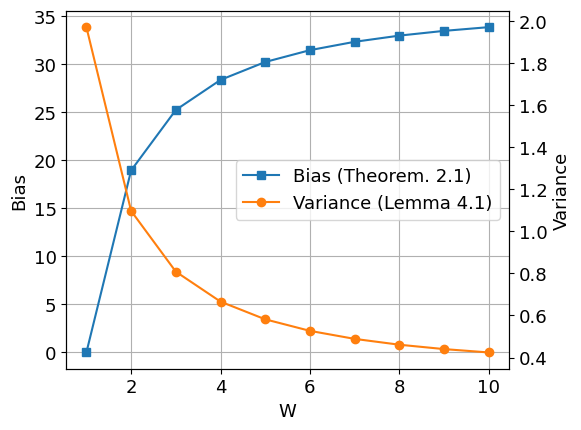

[ 1  2  3  4  5  6  7  8  9 10]


In [35]:
import numpy as np
import matplotlib.pyplot as plt
font = {'size'   : 13}
plt.rc('font', **font)  # pass in the font dict as kwargs

# Parametri
gamma_values = [0.5, 0.6, 0.7, 0.8, 0.9]
W_values = np.arange(1, 11, 1)
D = 0.1  # valore fisso di D per confronto

# Funzioni
def bias(D, W, gamma):
    return ((gamma / (1 - gamma) ** 2 - (gamma ** W * W) / (1 - gamma ** W) ** 2) * D) * 2

def bias_v2(D,W,gamma):
    return ((gamma * (1 - gamma ** (W-1))) / ((1 - gamma) ** 2 * (1 - gamma ** W))) * 4 * D
    
def variance(W, gamma=0.9, G2=1, H=10, N=100):
    term1 = 1 / ((1 - gamma) ** 2)
    term2 = (1 - gamma ** H) / (N * (1 - gamma ** W))
    term3 = (1 - (H / W) * (gamma ** H - gamma ** (H + W)) - gamma ** H)
    return term1 * term2 * term3

# Plot
fig, ax1 = plt.subplots(figsize=(6, 4.5))
ax2 = ax1.twinx()

# Plot Bias per ciascun valore di gamma
# for g in [0.9]:
# b_val = bias(D, W_values, 0.9)
b_val = bias_v2(D, W_values, 0.9)
# ax1.plot(W_values, b_val, label=f"Bias (Thm. 2.1)")
ax1.plot(W_values, b_val, marker='s', label="Bias (Theorem. 2.1)")

# Plot della varianza con gamma=0.9
v_val = variance(W_values, gamma=0.9)
# ax2.plot(W_values, v_val, color="tab:orange", label='Variance (Lemma 4.1)')
ax2.plot(W_values, v_val, marker='o', color="tab:orange", label='Variance (Lemma 4.1)')

# Labels
ax1.set_xlabel('W')
ax1.set_ylabel('Bias')
ax2.set_ylabel('Variance')

# Legende combinate
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

ax1.grid(True)
ax2.grid(True)
plt.grid()
plt.tight_layout()
# plt.savefig("bias_variance_combined_new.pdf", format='pdf')
tikz.save("bias_variance_combined.tex")
plt.show()

print(W_values)

# GAPS MLJ REDO

In [111]:
# idk
# "/Users/gianmarcotedeschi/Projects/learnRL/results/lq/04_11-18_59/H_10_g_09"
# "/Users/gianmarcotedeschi/Projects/learnRL/results/lq/04_15-16_46/H_10_g_09"
# "/Users/gianmarcotedeschi/Projects/learnRL/results/lq/04_16-17_57/H_10_g_09"


paths = [
    # HGAPS
    # "/Users/gianmarcotedeschi/Downloads/results_new/_03_31-02_06_agaps_h_1000_minigolf_200_adam_01_split_gaussian_h_batch_100_waiting_0_delta_window_30_l1_00_l2_00_patience_-1_maxsplits_50_node_selection_strategy_max_absolute_penalize_depth_1.0_von_mises_eval_1_clip_1_std_01_alpha_01", 
    # "/Users/gianmarcotedeschi/Downloads/results_new/_03_31-00_39_agaps_h_1000_half_cheetah_100_adam_01_split_gaussian_h_batch_100_waiting_0_delta_window_30_l1_00_l2_00_patience_-1_maxsplits_50_node_selection_strategy_max_absolute_penalize_depth_1.0_von_mises_eval_1_clip_6_std_01_alpha_01",
    # "/Users/gianmarcotedeschi/Downloads/results_new/_03_30-22_05_agaps_h_1000_swimmer_200_adam_001_split_gaussian_h_batch_100_waiting_0_delta_window_30_l1_00_l2_00_patience_-1_maxsplits_50_node_selection_strategy_max_absolute_penalize_depth_1.0_von_mises_eval_1_clip_2_std_01_alpha_01", 
    
    # "/Users/gianmarcotedeschi/Downloads/_04_09-15_01_agaps_h_1000_lq_1_1_10_adam_01_split_gaussian_h_batch_100_waiting_0_delta_window_30_l1_00_l2_00_patience_-1_maxsplits_50_node_selection_strategy_max_absolute_penalize_depth_1.0_von_mises_eval_1_clip_1_std_01_alpha_01",
    # "/Users/gianmarcotedeschi/Downloads/_04_09-15_12_agaps_h_1000_lq_1_1_10_adam_0005_split_gaussian_h_batch_100_waiting_0_delta_window_30_l1_00_l2_00_patience_-1_maxsplits_50_node_selection_strategy_max_absolute_penalize_depth_1.0_von_mises_eval_1_clip_1_std_01_alpha_01", 
    # "/Users/gianmarcotedeschi/Downloads/_04_09-15_06_agaps_h_1000_lq_1_1_10_adam_001_split_gaussian_h_batch_100_waiting_0_delta_window_30_l1_00_l2_00_patience_-1_maxsplits_50_node_selection_strategy_max_absolute_penalize_depth_1.0_von_mises_eval_1_clip_1_std_01_alpha_01",

    # "/Users/gianmarcotedeschi/Downloads/_04_09-20_24_agaps_h_1000_swimmer_200_adam_001_split_gaussian_h_batch_100_waiting_0_delta_window_30_l1_00_l2_00_patience_-1_maxsplits_50_node_selection_strategy_max_absolute_penalize_depth_1.0_von_mises_eval_1_clip_2_std_01_alpha_01", 
    "/Users/gianmarcotedeschi/Downloads/_04_09-21_43_agaps_h_1000_half_cheetah_100_adam_01_split_gaussian_h_batch_100_waiting_0_delta_window_30_l1_00_l2_00_patience_-1_maxsplits_50_node_selection_strategy_max_absolute_penalize_depth_1.0_von_mises_eval_1_clip_6_std_01_alpha_01",

    # GAPS
    # "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_05_20-21_45_split_1000_swimmer_200_constant_0001_split_gaussian_batch_100_clip_2_std_01_alpha_01", 
    # "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_12-14_24_agaps_1000_lq_10_constant_0001_split_gaussian_batch_100_clip_1_std_01_alpha_01",
    # "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_12-16_51_agaps_1000_minigolf_200_constant_001_split_gaussian_batch_100_clip_1_std_01_alpha_01",
    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/_12_12-18_54_agaps_1000_half_cheetah_100_adam_0001_split_gaussian_batch_200_clip_6_std_01_alpha_01",
    
    # RBF
    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_11-20_47_pg_1000_half_cheetah_100_adam_0001_gaussian_batch_100_clip_102_std_01_alpha_01", 
    # "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_11-20_47_pg_1000_swimmer_200_adam_0001_gaussian_batch_100_clip_16_std_01_alpha_01",
    # "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_12-14_29_pg_1000_lq_10_adam_0001_gaussian_batch_100_clip_1_std_01_alpha_01",
    # "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_12-15_01_pg_1000_minigolf_200_adam_0001_gaussian_batch_100_clip_1_std_01_alpha_01",

    # MLP
    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_12-19_50_pg_1000_half_cheetah_100_adam_0001_deep_gaussian_batch_100_clip_624_std_01_alpha_01", 
    # "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_12-19_21_pg_1000_minigolf_200_adam_0001_deep_gaussian_batch_100_clip_288_std_01_alpha_01",
    # "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_12-17_57_pg_1000_swimmer_200_adam_0001_deep_gaussian_batch_100_clip_416_std_1_alpha_01",
    # "/Users/gianmarcotedeschi/Desktop/Ok/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_12-17_43_pg_1000_lq_10_adam_0001_deep_gaussian_batch_100_clip_288_std_01_alpha_01",
 
    # NEAT
    # "/Users/gianmarcotedeschi/Projects/learnRL/results_old/results/swimmer/04_11-19_00/H_200_g_0995",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results_old/results/minigolf/04_11-18_59/H_200_g_0995",
    # "/Users/gianmarcotedeschi/Projects/learnRL/results_old/results/lq/04_16-18_05/H_10_g_09",
    "/Users/gianmarcotedeschi/Projects/learnRL/results_old/results/half_cheetah/04_11-19_00/H_100_g_0995"
]


lab = [
    "H-GAPS",
    "GAPS",
    "PG-RBF",
    "PG-MLP",
    "NEAT",
]

In [20]:
import os
import json
import numpy as np

# Funzione per caricare i dati da un percorso
def load_trials(base_path, n_exp):
    trial_performances = []
    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            for filename in ["results.json", "pg_results.json"]:
                file_path = os.path.join(trial_path, filename)
                if os.path.isfile(file_path):
                    try:
                        with open(file_path, 'r') as file:
                            data = json.load(file)
                            trial_performances.append(data["performance"])
                        break  # Se ha trovato e letto correttamente un file, esce dal ciclo interno
                    except (json.JSONDecodeError, KeyError) as e:
                        print(f"Errore nel leggere {file_path}: {e}")
                        break  # Se il file esiste ma è malformato, non provare l'altro
    return np.array(trial_performances)  # Converte in array per calcoli successivi


In [112]:
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=10)
    if performances.size > 0:
        all_performances.append(performances)

In [47]:
print(len(all_performances))

5


0
72.39892873679466
60.8016748493116
83.99618262427772
1
75.60828012623531
75.18492404690085
76.03163620556977
2
172.25315507743377
156.48998837097938
188.01632178388812
3
127.95363524414041
109.71446577796476
146.19280471031607
4
36.37890805761998
20.586399013705822
52.171417101534146


<Figure size 640x480 with 0 Axes>

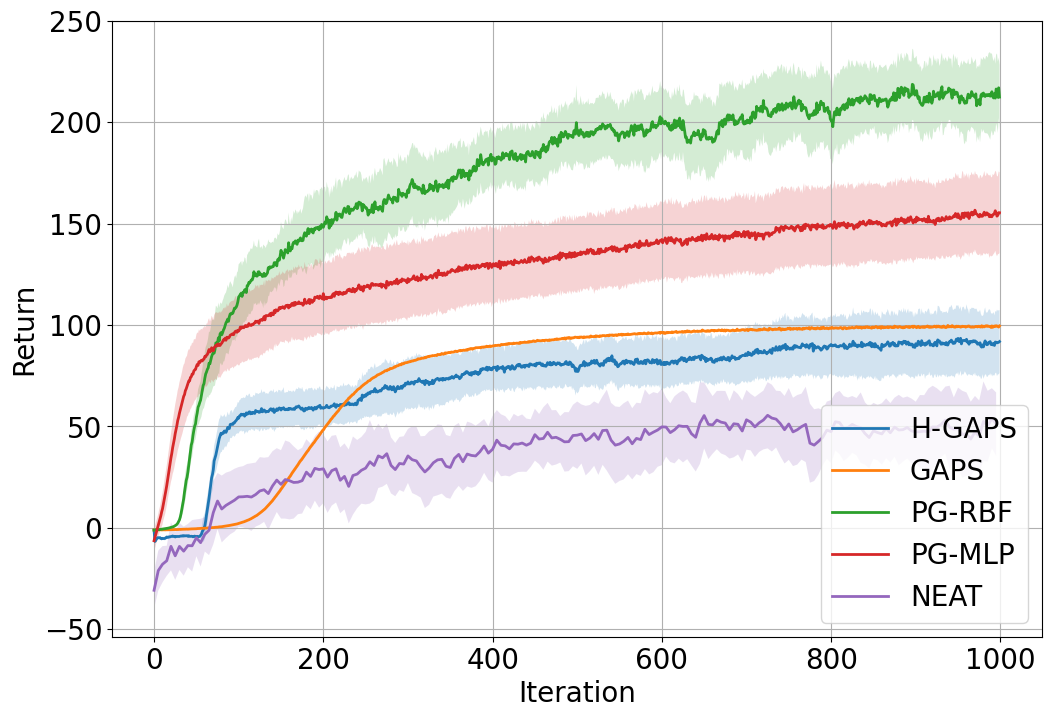

In [ ]:
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(12, 8))
max_length = max(perf.shape[1] for perf in all_performances if perf.size > 0)

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)
        
        length = len(mean_performance)

        # Asse x: se il numero di punti è minore del massimo, scala l'asse
        if length < max_length:
            step = max_length // length
            x_vals = np.arange(0resre, max_length, step)
            # In caso di divisione imperfetta, taglia l'array per sicurezza
            mean_performance = mean_performance[:len(x_vals)]
            std_performance = std_performance[:len(x_vals)]
        else:
            x_vals = np.arange(length)

        # Plot della curva media
        print(i)
        plt.plot(x_vals, mean_performance, linewidth=2, label=lab[i])

        # Plot dell'intervallo di confidenza
        lower = mean_performance-(std_performance)*1.96/np.sqrt(performances.shape[0])
        higher = mean_performance+(std_performance)*1.96/np.sqrt(performances.shape[0])

        plt.fill_between(
            x_vals,
            lower,
            higher,
            alpha=0.2
        )

        print(np.mean(mean_performance))
        print(np.mean(lower))
        print(np.mean(higher))

# Etichette e titolo
# plt.title("Swimmer")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend(loc="best")
plt.grid()
# plt.ylim(bottom=-125)
# plt.xlim(right=80)
# Salva e mostra il grafico
# plt.savefig("gaps-thesis/lq_gaps_final.pdf", format='pdf')
# tikz.save('gaps-thesis/lq_comparison.tex')
plt.show()


<Figure size 640x480 with 0 Axes>

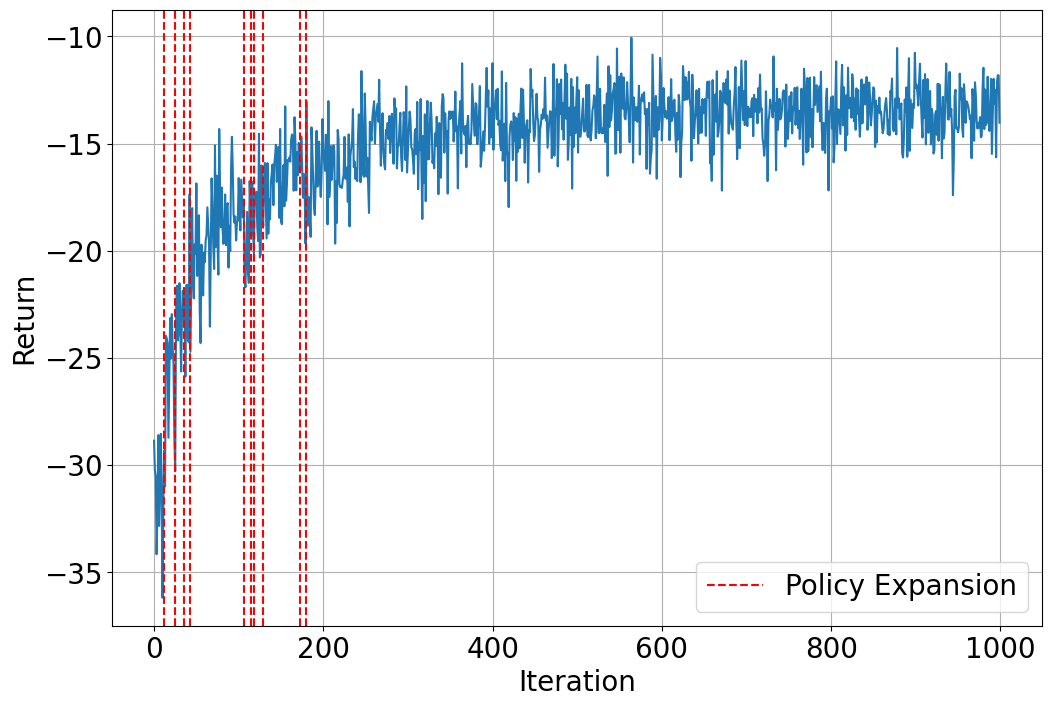

In [104]:
# Path to results_debug
path = [
    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-MLJ/risultati/results/results_ok/_12_12-14_24_agaps_1000_lq_10_constant_0001_split_gaussian_batch_100_clip_1_std_01_alpha_01/trial_0",
]

data = []
for p in path:
    name = p + "/pg_results.json"
    with open(name) as file:
        data.append(json.load(file))

plt.clf()
plt.figure(figsize=(12, 8))
# extract data
for i, d in enumerate(data):
    ite = len(d["performance"])
    x = np.arange(ite)
    dim = len(d["thetas_history"][0])
    # Performance plot
    plt.plot(x, d["performance"])
    
    
for point in d["split_ite"]:
    plt.axvline(x=point, color='r', linestyle='--', label='Policy Expansion' if point == d["split_ite"][0] else None)

plt.xlabel("Iteration")
plt.ylabel("Return")
plt.legend(loc="best")
plt.grid()
plt.savefig("gaps-thesis/lq_split.pdf", format='pdf')
tikz.save('gaps-thesis/lq_split.tex')
plt.show()

[38, 52, 70, 76, 85]


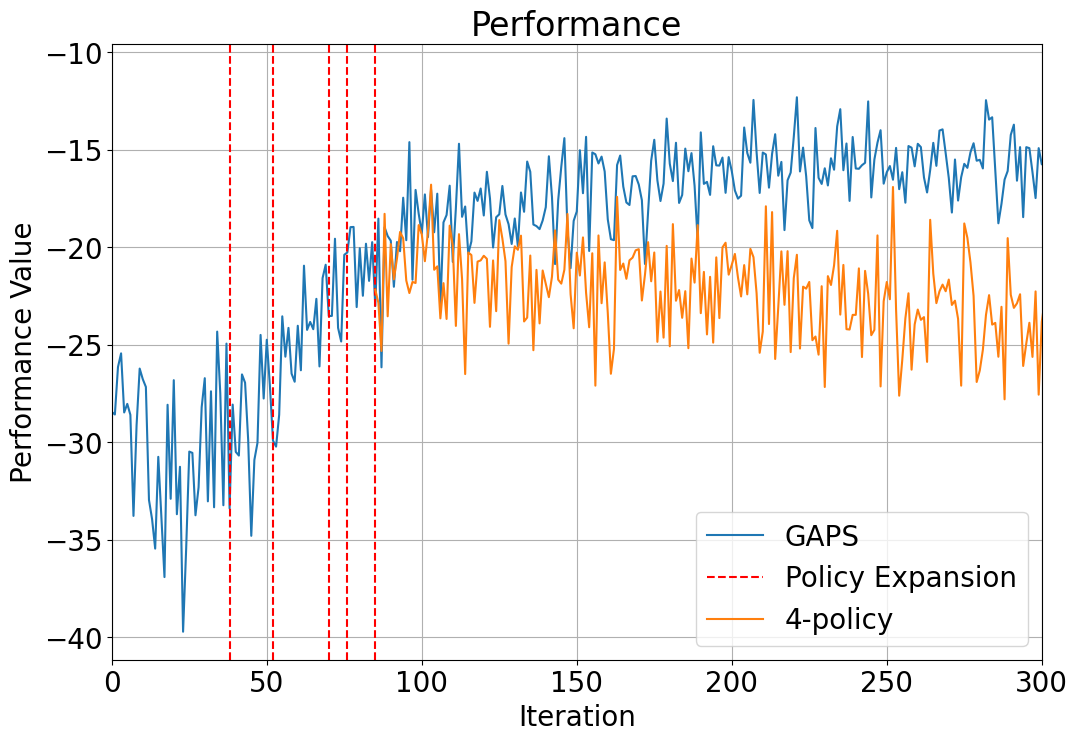

In [129]:
from scipy.interpolate import make_interp_spline

# Function to smooth data using spline interpolation
def smooth_data(x, y, points=300):
    x_smooth = np.linspace(x.min(), x.max(), points)
    spline = make_interp_spline(x, y, k=3)  # Cubic spline
    y_smooth = spline(x_smooth)
    return x_smooth, y_smooth

# Path to results_debug
path_main = ["/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-NIPS/GAPS_result_NIPS/results/_05_21-22_45_split_500_lq_10_constant_0001_split_gaussian_batch_100_clip_1_std_01_alpha_01/trial_3"]

path_lin = [
    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-NIPS/GAPS_result_NIPS/results/_05_22-00_12_pg_500_lq_10_adam_1e-05_gaussian_batch_100_clip_1_std_01_alpha_01/trial_0",
    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-NIPS/GAPS_result_NIPS/results/_05_22-00_11_pg_500_lq_10_adam_1e-05_gaussian_batch_100_clip_1_std_01_alpha_01/trial_0",
    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-NIPS/GAPS_result_NIPS/results/_05_22-00_10_pg_500_lq_10_adam_1e-05_gaussian_batch_100_clip_1_std_01_alpha_01/trial_0",
    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-NIPS/GAPS_result_NIPS/results/_05_22-00_09_pg_500_lq_10_adam_1e-05_gaussian_batch_100_clip_1_std_01_alpha_01/trial_0",
    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-NIPS/GAPS_result_NIPS/results/_05_22-00_07_pg_500_lq_10_adam_1e-05_gaussian_batch_100_clip_1_std_01_alpha_01/trial_0",
    "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-NIPS/GAPS_result_NIPS/results/_05_22-10_24_pg_500_lq_10_adam_1e-05_gaussian_batch_100_clip_1_std_01_alpha_01/trial_0",
]

data = []
for p in path_main:
    name = p + "/split_results.json"
    file = open(name)
    data.append(json.load(file))

data_lin = []
for p in path_lin:
    name = p + "/pg_results.json"
    file = open(name)
    data_lin.append(json.load(file))

fig, ax = plt.subplots(figsize=(12, 8))

for i, d in enumerate(data):
    ite = len(d["performance"])
    x = np.arange(ite)
    y = d["performance"]
    x_smooth, y_smooth = smooth_data(x, y)
    dim = len(d["thetas_history"][0])
    # Performance plot
    plt.plot(x, d["performance"], label=f"GAPS")
    #plt.plot(x_smooth, y_smooth, label=f"GAPS")

split = []
for point in d["split_ite"]:
    plt.axvline(x=point, color='r', linestyle='--', label='Policy Expansion' if point == d["split_ite"][0] else None)
    split = d["split_ite"]

print(split)
for i, d in enumerate(data_lin):
    ite = len(d["performance"])
    x = np.arange(ite)
    # dim = len(d["thetas_history"][0])
    # # Performance plot
    # plt.plot(x, d["performance"][:-(split[i])], label=f"{i}-policy")
    if i == 1 or i == 3 or i == 2 or i == 0:
        # ax.plot(x, d["performance"], label=f"{i}-policy")
        continue
    if i == len(data_lin)-1:
        break

    # start_index = split[i-1] if i-1 < len(split) else split[0]
    start_index = split[i]
    # Adjust x and y to start from start_index
    if start_index < ite:
        x = x[start_index:]
        y = d["performance"][start_index:]
        x_smooth, y_smooth = smooth_data(x, y)
        ax.plot(x, y, label=f"{i}-policy")
        # ax.plot(x_smooth, y_smooth, label=f"{i}-policy")

plt.title("Performance")
plt.xlabel("Iteration")
plt.ylabel("Performance Value")
plt.legend(loc="best")
plt.xlim(0, 300)  # Set the x-axis limit to the cutoff
plt.grid()
plt.savefig("gaps-thesis/lq_1_policy_analysis_4-res.pdf", format='pdf')
tikz.save('gaps-thesis/lq_1_policy_analysis_4-res.tex')



In [4]:
import sys
sys.path.append('/Users/gianmarcotedeschi/Projects/learnRL/')


In [8]:
import os
import sys

print("cwd:", os.getcwd())
print("has project root:", "/Users/gianmarcotedeschi/Projects/learnRL" in sys.path)
print("common exists:", os.path.exists("/Users/gianmarcotedeschi/Projects/learnRL/common"))
print("tree exists:", os.path.exists("/Users/gianmarcotedeschi/Projects/learnRL/common/tree.py"))
print("common init exists:", os.path.exists("/Users/gianmarcotedeschi/Projects/learnRL/common/__init__.py"))
print(sys.path[:5])

cwd: /Users/gianmarcotedeschi/Projects/learnRL/notebooks
has project root: True
common exists: True
tree exists: True
common init exists: True
['/Users/gianmarcotedeschi/Projects/learnRL/notebooks', '/', '/Users/gianmarcotedeschi/Projects/BHAI24_Online', '/opt/homebrew/Caskroom/miniconda/base/envs/phd-env-39/lib/python39.zip', '/opt/homebrew/Caskroom/miniconda/base/envs/phd-env-39/lib/python3.9']


[(1.549956618205852, array([       -inf, -2.69437877])), (0.8811663088015115, array([-2.69437877, -1.98029548])), (0.7653426868314729, array([-1.98029548, -1.4078594 ])), (0.440343046749194, array([-1.4078594 , -0.47334856])), (0.09403211961659064, array([-0.47334856, -0.06580675])), (0.027510049901335133, array([-0.06580675, -0.        ])), (-0.04207652695548744, array([-0.        ,  0.13443539])), (-0.16930703475999337, array([0.13443539, 0.71327489])), (-0.6344218395474434, array([0.71327489, 1.86488592])), (-0.994024912311888, array([1.86488592, 2.93369821])), (-1.3676620385608733, array([2.93369821,        inf]))]


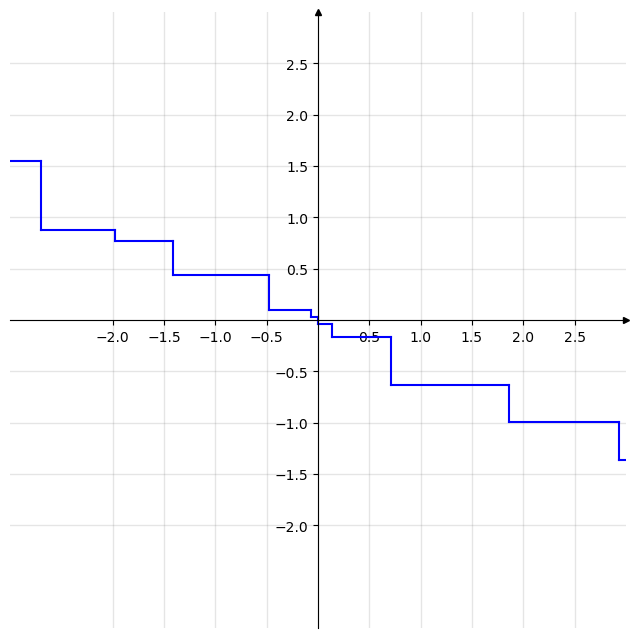

In [4]:
import os
import sys
import pickle
import importlib
import numpy as np
import matplotlib.pyplot as plt
import tikzplotlib as tikz

project_root = "/Users/gianmarcotedeschi/Projects/learnRL"
if project_root not in sys.path:
    sys.path.insert(0, project_root)
else:
    sys.path.remove(project_root)
    sys.path.insert(0, project_root)

if "common" in sys.modules:
    del sys.modules["common"]
if "common.tree" in sys.modules:
    del sys.modules["common.tree"]

import common.tree
importlib.reload(common.tree)

tree_file = "/Users/gianmarcotedeschi/Desktop/ok/Polimi/Ricerca/GAPS/GAPS-NIPS/GAPS_result_NIPS/results/_05_21-20_22_split_1000_lq_10_constant_0001_split_gaussian_batch_100_clip_1_std_01_alpha_01/trial_3/policy_tree"

with open(tree_file, "rb") as f:
    tree = pickle.load(f)

leaves = tree.get_all_leaves()
policy = tree.get_current_policy()

regions = []
for node in tree.get_all_leaves():
    regions.append(tree.get_region(node, 1))

policy = np.array(policy).ravel()

ordered_policy = sorted(zip(policy, np.array(regions).squeeze()), key=lambda x: x[1][0])

print(ordered_policy)

# font = {'size'   : 7}        
# plt.rc('font', **font)

xmin = -2
xmax = 2
ymin = -2
ymax = 2
ticks_frequency = 0.5

fig, ax = plt.subplots(figsize=(12, 8))

for i, (number, interval) in enumerate(ordered_policy):
    lower_bound, upper_bound = interval
    if upper_bound == np.inf:
        upper_bound = 5
    if lower_bound == -np.inf:
        lower_bound = -5
    plt.plot([lower_bound, upper_bound], [number, number], color='blue')  # Horizontal line for the interval
    
    # Draw vertical line connecting to the next interval, if it's not the last interval
    if i < len(ordered_policy) - 1:
        next_number, next_interval = ordered_policy[i + 1]
        next_lower_bound, _ = next_interval
        plt.plot([upper_bound, upper_bound], [number, next_number], color='blue')  # Vertical line down to the next interval's lower bound

plt.grid()

ax.set(xlim=(xmin-1, xmax+1), ylim=(ymin-1, ymax+1), aspect='equal')

ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# Create 'x' and 'y' labels placed at the end of the axes
# ax.set_xlabel('x', size=5, labelpad=-24, x=1.03)
# ax.set_ylabel('y', size=5, labelpad=-21, y=1.02, rotation=0)

x_ticks = np.arange(xmin, xmax+1, ticks_frequency)
y_ticks = np.arange(ymin, ymax+1, ticks_frequency)
ax.set_xticks(x_ticks[x_ticks != 0])
ax.set_yticks(y_ticks[y_ticks != 0])

ax.set_xticks(np.arange(xmin, xmax+1), minor=True)
ax.set_yticks(np.arange(ymin, ymax+1), minor=True)
# ax.tick_params(labelbottom=False)    

# Draw major and minor grid lines
ax.grid(which='both', color='grey', linewidth=1, linestyle='-', alpha=0.2)

# Draw arrows
arrow_fmt = dict(markersize=4, color='black', clip_on=False)
ax.plot((1), (0), marker='>', transform=ax.get_yaxis_transform(), **arrow_fmt)
ax.plot((0), (1), marker='^', transform=ax.get_xaxis_transform(), **arrow_fmt)
plt.savefig("gaps-thesis/lq_1_policy-res.pdf", format='pdf')
if tikz is not None:
    tikz.save('gaps-thesis/lq_1_policy-res.tex')

plt.show()